# Gradient Strength and Geometric Distortion in MRI

MRI gradients encode spatial position into the acquired MR signal.

Image reconstruction assumes that the gradients produced by the scanner match the gradients requested by the imaging sequence.

But what happens if the **actual gradient strength differs from the expected gradient strength?**

In this notebook, we will explore this problem in two steps:

### Part 1 — 1D experiment

We will investigate how changing gradient strength affects:

- frequency encoding,
- k-space sampling,
- encoded field of view (FOV),
- spatial resolution / voxel size,
- and the reconstructed position of an object.

### Part 2 — 2D experiment

We will apply the same gradient error to a two-dimensional digital phantom and observe the resulting geometric distortion.

The gradient will remain perfectly **linear** throughout this experiment.

Only its amplitude will change.

# Part 1 — 1D Gradient Experiment

## 1. Define the imaging space

We will begin with a simple one-dimensional imaging experiment.

The nominal imaging parameters are:

$$
\mathrm{FOV}_{\mathrm{nominal}} = 200\ \mathrm{mm}
$$

and

$$
N = 256.
$$

Therefore, the nominal spatial sampling interval is

$$
\Delta x_{\mathrm{nominal}}
=
\frac{\mathrm{FOV}_{\mathrm{nominal}}}{N}.
$$

For this experiment,

$$
\Delta x_{\mathrm{nominal}}
=
\frac{200}{256}
=
0.78125\ \mathrm{mm}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Nominal imaging parameters
# --------------------------------------------------

N = 256
FOV_nominal = 200.0  # mm

dx_nominal = FOV_nominal / N

# Nominal reconstructed spatial coordinates
x = (np.arange(N) - N / 2) * dx_nominal

print(f"Matrix size         : {N}")
print(f"Nominal FOV         : {FOV_nominal:.1f} mm")
print(f"Nominal voxel size  : {dx_nominal:.5f} mm")

Matrix size         : 256
Nominal FOV         : 200.0 mm
Nominal voxel size  : 0.78125 mm


## 2. Position and frequency

During frequency encoding, a linear gradient causes the Larmor frequency to vary with position.

The frequency offset of a spin located at position $x$ is

$$
\Delta f(x)
=
\bar{\gamma}G_xx
$$

where:

- $x$ is position in image space,
- $G_x$ is the frequency-encoding gradient,
- $\bar{\gamma}$ is the proton gyromagnetic ratio in Hz/T.

For protons,

$$
\bar{\gamma}
\approx
42.58\times10^6\ \mathrm{Hz/T}.
$$

Therefore, a linear gradient establishes a linear relationship between **position** and **frequency**.

In [2]:
# Proton gyromagnetic ratio
gamma_hz = 42.58e6  # Hz/T

# Nominal readout gradient
G_nominal = 20.0  # mT/m

# Convert gradient to T/m
G_nominal_Tm = G_nominal * 1e-3

print(f"Nominal gradient = {G_nominal:.1f} mT/m")

Nominal gradient = 20.0 mT/m


## 3. Change the gradient strength

We will now allow the actual gradient to differ from the nominal gradient.

Define the gradient scaling factor as

$$
s
=
\frac{G_{\mathrm{actual}}}
{G_{\mathrm{nominal}}}.
$$

For example:

A 30% reduction gives

$$
s=0.70,
$$

while a 30% increase gives

$$
s=1.30.
$$

Therefore,

$$
G_{\mathrm{actual}}
=
sG_{\mathrm{nominal}}.
$$

In [3]:
gradient_errors = np.arange(-30, 31, 10)

gradient_scales = 1 + gradient_errors / 100

G_actual_values = G_nominal * gradient_scales

for error, scale, G in zip(
    gradient_errors,
    gradient_scales,
    G_actual_values
):
    print(
        f"{error:+3d}%  ->  "
        f"scale = {scale:.2f}  ->  "
        f"G = {G:.1f} mT/m"
    )

-30%  ->  scale = 0.70  ->  G = 14.0 mT/m
-20%  ->  scale = 0.80  ->  G = 16.0 mT/m
-10%  ->  scale = 0.90  ->  G = 18.0 mT/m
 +0%  ->  scale = 1.00  ->  G = 20.0 mT/m
+10%  ->  scale = 1.10  ->  G = 22.0 mT/m
+20%  ->  scale = 1.20  ->  G = 24.0 mT/m
+30%  ->  scale = 1.30  ->  G = 26.0 mT/m


## 4. Effect on frequency encoding

Because

$$
\Delta f(x)=\bar{\gamma}G_xx,
$$

changing the gradient changes the frequency produced at every spatial position.

A weaker gradient produces a smaller frequency offset.

A stronger gradient produces a larger frequency offset.

Let's examine the frequency-position relationship for:

- 30% weaker gradient,
- nominal gradient,
- 30% stronger gradient.

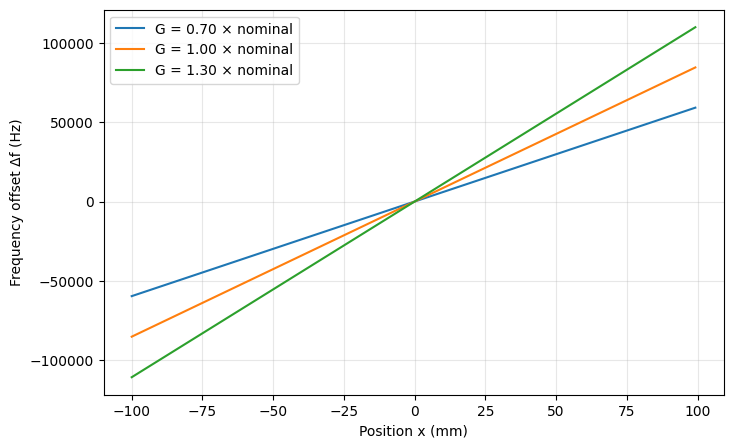

In [4]:
# Convert position from mm to m
x_m = x * 1e-3

plt.figure(figsize=(8, 5))

for scale in [0.70, 1.00, 1.30]:

    G_actual_Tm = (
        scale * G_nominal * 1e-3
    )

    df = (
        gamma_hz *
        G_actual_Tm *
        x_m
    )

    plt.plot(
        x,
        df,
        label=f"G = {scale:.2f} × nominal"
    )

plt.xlabel("Position x (mm)")
plt.ylabel("Frequency offset Δf (Hz)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 5. Gradient strength determines k-space position

The frequency-encoding gradient determines the trajectory through k-space.

For a readout gradient,

$$
k_x(t)
=
\bar{\gamma}
\int_0^t G_x(\tau)\,d\tau.
$$

If the shape and duration of the gradient remain unchanged, but its amplitude is multiplied by $s$, then

$$
k_{x,\mathrm{actual}}
=
s\,k_{x,\mathrm{nominal}}.
$$

Therefore, changing gradient amplitude changes both:

$$
\Delta k_x
$$

and

$$
k_{x,\max}.
$$

This has consequences for both FOV and spatial resolution.

## 6. Effect on the encoded FOV

The relationship between k-space sampling interval and FOV is

$$
\mathrm{FOV}
=
\frac{1}{\Delta k}.
$$

If

$$
\Delta k_{\mathrm{actual}}
=
s\Delta k_{\mathrm{nominal}},
$$

then

$$
\boxed{
\mathrm{FOV}_{\mathrm{actual}}
=
\frac{\mathrm{FOV}_{\mathrm{nominal}}}{s}
}
$$

Therefore, a weaker gradient produces a larger encoded FOV, while a stronger gradient produces a smaller encoded FOV.

## 7. Effect on spatial resolution

The spatial sampling interval is related to the sampled k-space extent.

Approximately,

$$
\Delta x
\approx
\frac{1}{2k_{\max}}.
$$

Since

$$
k_{\max,\mathrm{actual}}
=
s\,k_{\max,\mathrm{nominal}},
$$

the physical spatial sampling interval becomes

$$
\boxed{
\Delta x_{\mathrm{actual}}
=
\frac{\Delta x_{\mathrm{nominal}}}{s}
}
$$

Therefore:

- weaker gradient $\rightarrow$ larger physical voxel size,
- stronger gradient $\rightarrow$ smaller physical voxel size.

Error    Scale    FOV (mm)    Voxel size (mm)
------------------------------------------------
-30%     0.70       285.71         1.1161
-20%     0.80       250.00         0.9766
-10%     0.90       222.22         0.8681
 +0%     1.00       200.00         0.7812
+10%     1.10       181.82         0.7102
+20%     1.20       166.67         0.6510
+30%     1.30       153.85         0.6010


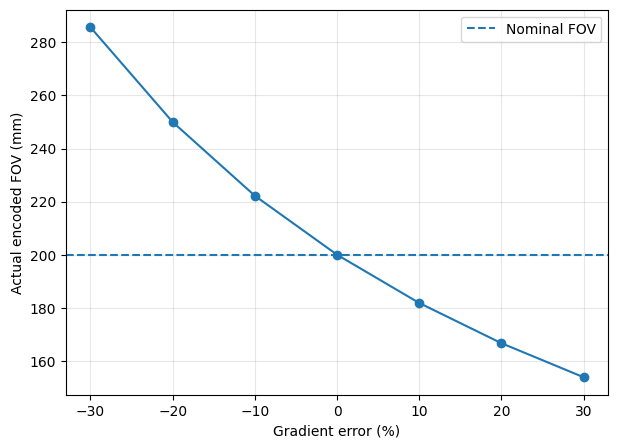

In [6]:
FOV_actual = (
    FOV_nominal / gradient_scales
)

dx_actual = (
    dx_nominal / gradient_scales
)

print(
    "Error    Scale    FOV (mm)    "
    "Voxel size (mm)"
)

print("-" * 48)

for error, scale, fov, dx_a in zip(
    gradient_errors,
    gradient_scales,
    FOV_actual,
    dx_actual
):

    print(
        f"{error:+3d}%     "
        f"{scale:4.2f}      "
        f"{fov:7.2f}        "
        f"{dx_a:7.4f}"
    )

plt.figure(figsize=(7, 5))

plt.plot(
    gradient_errors,
    FOV_actual,
    marker="o"
)

plt.axhline(
    FOV_nominal,
    linestyle="--",
    label="Nominal FOV"
)

plt.xlabel("Gradient error (%)")
plt.ylabel("Actual encoded FOV (mm)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Reconstruction with the wrong spatial calibration

The scanner does not necessarily know that the actual gradient was different.

Suppose reconstruction continues to assume the nominal gradient and nominal FOV.

The measured frequency is

$$
\Delta f_{\mathrm{measured}}
=
\bar{\gamma}
G_{\mathrm{actual}}
x_{\mathrm{true}}.
$$

But reconstruction converts this frequency to position using

$$
x_{\mathrm{recon}}
=
\frac{
\Delta f_{\mathrm{measured}}
}{
\bar{\gamma}G_{\mathrm{nominal}}
}.
$$

Substituting gives

$$
x_{\mathrm{recon}}
=
\frac{
G_{\mathrm{actual}}
}{
G_{\mathrm{nominal}}
}
x_{\mathrm{true}}.
$$

Therefore,

$$
\boxed{
x_{\mathrm{recon}}
=
s\,x_{\mathrm{true}}
}
$$

This is a geometric scaling about the gradient isocenter.

It is **not a uniform translation of the image**.

## 9. Follow one point in the image

Consider an object physically located at

$$
x_{\mathrm{true}}
=
50\ \mathrm{mm}.
$$

If the gradient is 30% weaker,

$$
s=0.70,
$$

and therefore

$$
x_{\mathrm{recon}}
=
0.70\times50
=
35\ \mathrm{mm}.
$$

If the gradient is 30% stronger,

$$
s=1.30,
$$

then

$$
x_{\mathrm{recon}}
=
1.30\times50
=
65\ \mathrm{mm}.
$$

Let's follow this point as the gradient changes.

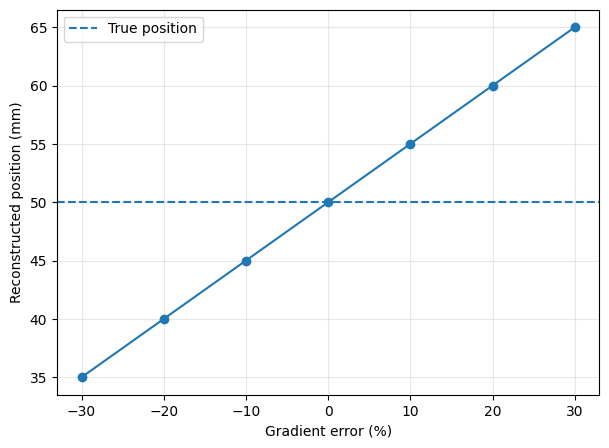

In [7]:
x_true = 50.0  # mm

x_reconstructed = (
    gradient_scales * x_true
)

plt.figure(figsize=(7, 5))

plt.plot(
    gradient_errors,
    x_reconstructed,
    marker="o"
)

plt.axhline(
    x_true,
    linestyle="--",
    label="True position"
)

plt.xlabel("Gradient error (%)")
plt.ylabel("Reconstructed position (mm)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Important distinction

For a 30% weaker gradient,

$$
s=0.70.
$$

The actual encoded FOV becomes

$$
\mathrm{FOV}_{\mathrm{actual}}
=
\frac{200}{0.70}
=
285.7\ \mathrm{mm}.
$$

The actual spatial sampling interval becomes

$$
\Delta x_{\mathrm{actual}}
=
\frac{0.78125}{0.70}
=
1.116\ \mathrm{mm}.
$$

These represent increases of approximately **42.9%**, not 30%.

However, if reconstruction still labels the image using the nominal 200 mm FOV, reconstructed positions follow

$$
x_{\mathrm{recon}}
=
0.70x_{\mathrm{true}}.
$$

Therefore, the object's apparent dimensions are **compressed by 30%** along that direction.

These are two descriptions of the same spatial calibration mismatch:

$$
\boxed{
\text{Actual encoded FOV changes as }1/s
}
$$

while

$$
\boxed{
\text{Apparent image geometry changes as }s
}
$$

# Part 2 — Geometric Distortion in a 2D Phantom

We will now apply the same concept to a two-dimensional object.

Our phantom will contain:

- a large circular background object,
- two smaller ring-shaped structures.

Because the structures are circular, geometric scaling along one direction will be easy to observe.

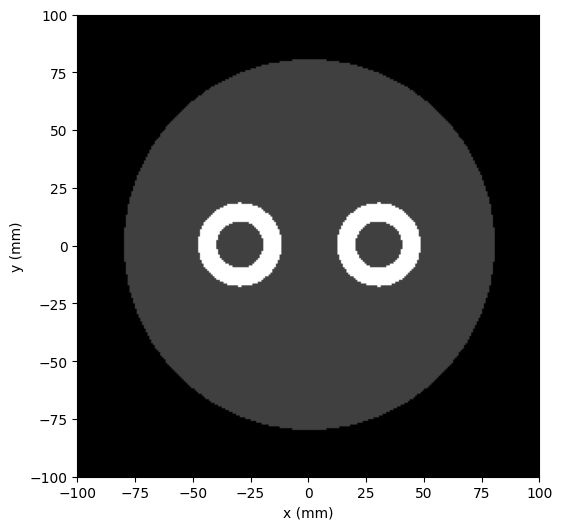

In [8]:
# --------------------------------------------------
# 2D spatial coordinates
# --------------------------------------------------

x2 = (np.arange(N) - N / 2) * dx_nominal
y2 = (np.arange(N) - N / 2) * dx_nominal

X, Y = np.meshgrid(x2, y2)

# --------------------------------------------------
# Create digital phantom
# --------------------------------------------------

phantom = np.zeros((N, N), dtype=float)

# Large circular background
R_background = 80.0  # mm

background = (
    X**2 + Y**2
) <= R_background**2

phantom[background] = 0.25


# Two ring structures
ring_centers = [-30.0, 30.0]

R_inner = 10.0
R_outer = 18.0

for xc in ring_centers:

    R = np.sqrt(
        (X - xc)**2 +
        Y**2
    )

    ring = (
        (R >= R_inner) &
        (R <= R_outer)
    )

    phantom[ring] = 1.0

plt.figure(figsize=(6, 6))

plt.imshow(
    phantom,
    cmap="gray",
    origin="lower",
    extent=[
        -FOV_nominal / 2,
         FOV_nominal / 2,
        -FOV_nominal / 2,
         FOV_nominal / 2
    ]
)

plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axis("image")

plt.show()

## 10. Extending the gradient error to two dimensions

In two dimensions, spatial encoding occurs along both $x$ and $y$.

We can define separate gradient scaling factors:

$$
s_x
=
\frac{
G_{x,\mathrm{actual}}
}{
G_{x,\mathrm{nominal}}
}
$$

and

$$
s_y
=
\frac{
G_{y,\mathrm{actual}}
}{
G_{y,\mathrm{nominal}}
}.
$$

The reconstructed coordinates then become

$$
\boxed{
x_{\mathrm{recon}}
=
s_xx_{\mathrm{true}}
}
$$

and

$$
\boxed{
y_{\mathrm{recon}}
=
s_yy_{\mathrm{true}}.
}
$$

Therefore, gradient errors along different directions can produce different geometric scaling along $x$ and $y$.

## 11. Experiment A — Change only the x-gradient

First, keep the $y$ gradient correct:

$$
s_y=1.
$$

Now vary only the $x$ gradient.

We will compare:

$$
s_x=0.70,
$$

$$
s_x=1.00,
$$

and

$$
s_x=1.30.
$$

Before running the next cell, predict what will happen to the circular structures.

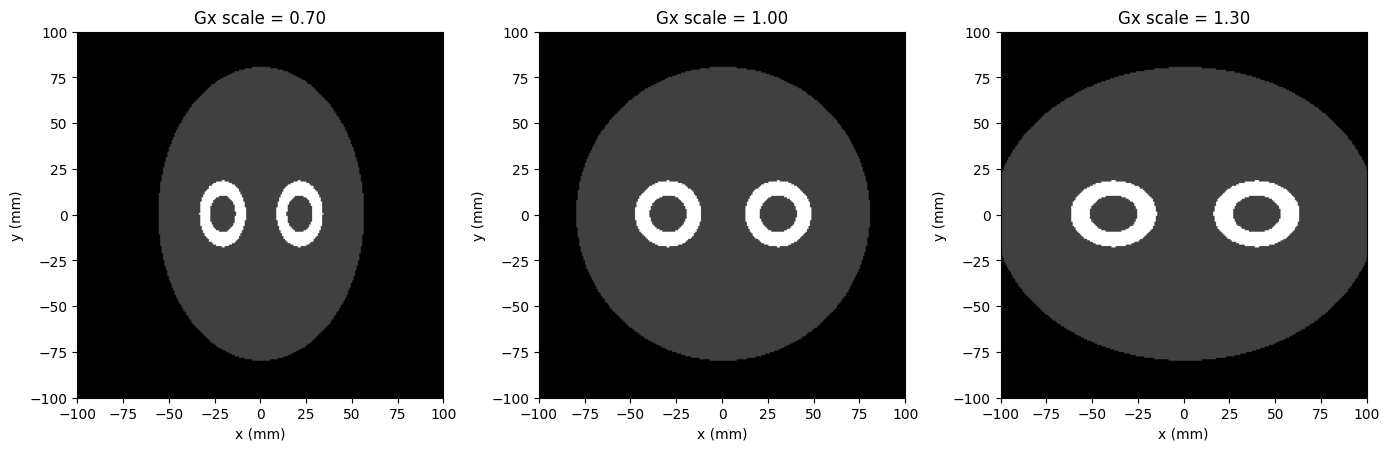

In [10]:
def generate_encoded_phantom(scale_x=1.0, scale_y=1.0):
    """
    Generate the reconstructed phantom geometry produced
    by uniform gradient calibration errors.

    scale_x = Gx_actual / Gx_nominal
    scale_y = Gy_actual / Gy_nominal
    """

    # Mapping from nominal reconstructed coordinates
    # back to the corresponding true physical position

    X_true = X / scale_x
    Y_true = Y / scale_y

    image = np.zeros((N, N), dtype=float)

    # Background
    background = (
        X_true**2 +
        Y_true**2
    ) <= R_background**2

    image[background] = 0.25

    # Rings
    for xc in ring_centers:

        R = np.sqrt(
            (X_true - xc)**2 +
            Y_true**2
        )

        ring = (
            (R >= R_inner) &
            (R <= R_outer)
        )

        image[ring] = 1.0

    return image

scale_values = [0.70, 1.00, 1.30]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

for ax, scale_x in zip(
    axes,
    scale_values
):

    image = generate_encoded_phantom(
        scale_x=scale_x,
        scale_y=1.0
    )

    ax.imshow(
        image,
        cmap="gray",
        origin="lower",
        extent=[
            -FOV_nominal / 2,
             FOV_nominal / 2,
            -FOV_nominal / 2,
             FOV_nominal / 2
        ]
    )

    ax.set_title(
        f"Gx scale = {scale_x:.2f}"
    )

    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.axis("image")

plt.tight_layout()
plt.show()

### Observe the geometry

When

$$
s_x=0.70,
$$

the phantom is compressed along $x$.

When

$$
s_x=1.00,
$$

the geometry is correct.

When

$$
s_x=1.30,
$$

the phantom is expanded along $x$.

The $y$ dimension remains unchanged because

$$
s_y=1.
$$

Notice that the circular structures become elliptical when the gradient error occurs along only one direction.

## 12. Experiment B — Change only the y-gradient

Now we will keep the $x$ gradient correct:

$$
s_x=1,
$$

and vary only the $y$ gradient.

Again, predict the direction of the geometric distortion before running the experiment.

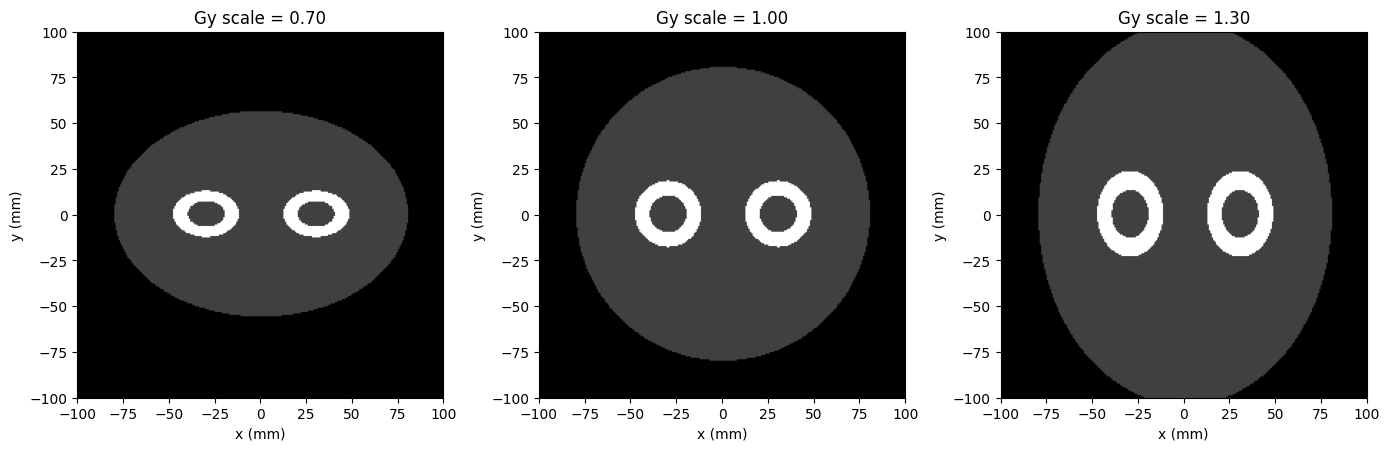

In [11]:
scale_values = [0.70, 1.00, 1.30]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

for ax, scale_y in zip(
    axes,
    scale_values
):

    image = generate_encoded_phantom(
        scale_x=1.0,
        scale_y=scale_y
    )

    ax.imshow(
        image,
        cmap="gray",
        origin="lower",
        extent=[
            -FOV_nominal / 2,
             FOV_nominal / 2,
            -FOV_nominal / 2,
             FOV_nominal / 2
        ]
    )

    ax.set_title(
        f"Gy scale = {scale_y:.2f}"
    )

    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.axis("image")

plt.tight_layout()
plt.show()

## 13. Experiment C — Change both gradients

Finally, let's change both spatial-encoding gradients.

If

$$
s_x=s_y=s,
$$

then

$$
x_{\mathrm{recon}}
=
sx_{\mathrm{true}}
$$

and

$$
y_{\mathrm{recon}}
=
sy_{\mathrm{true}}.
$$

Because both directions are scaled equally, the shape of a circular object remains circular.

However, its reconstructed size changes.

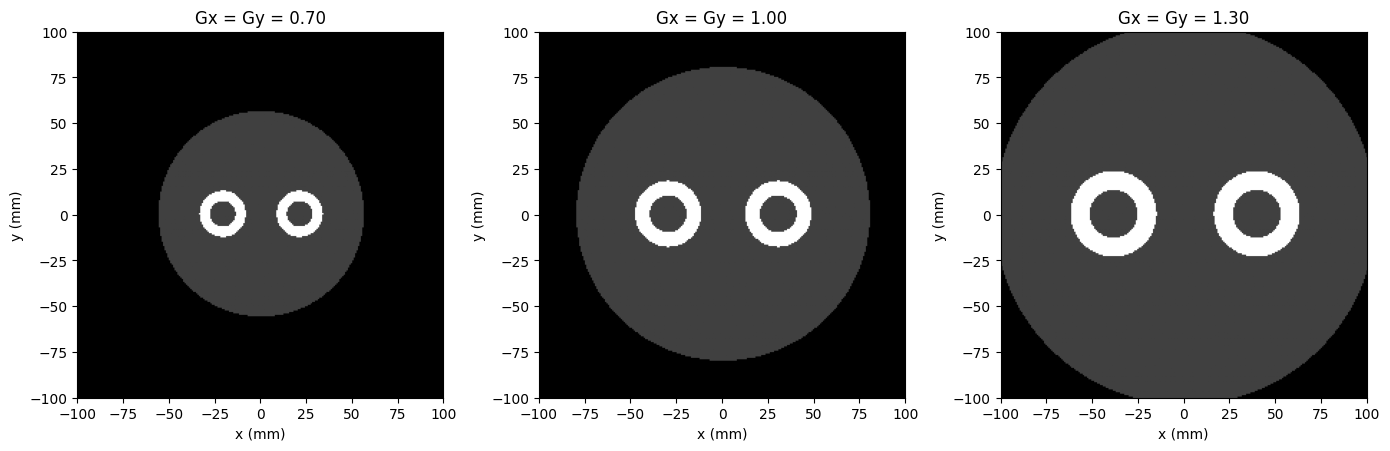

In [12]:
scale_values = [0.70, 1.00, 1.30]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

for ax, scale in zip(
    axes,
    scale_values
):

    image = generate_encoded_phantom(
        scale_x=scale,
        scale_y=scale
    )

    ax.imshow(
        image,
        cmap="gray",
        origin="lower",
        extent=[
            -FOV_nominal / 2,
             FOV_nominal / 2,
            -FOV_nominal / 2,
             FOV_nominal / 2
        ]
    )

    ax.set_title(
        f"Gx = Gy = {scale:.2f}"
    )

    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.axis("image")

plt.tight_layout()
plt.show()

## 14. What is happening in k-space?

The geometric changes originate from the spatial encoding.

For the $x$ direction,

$$
k_{x,\mathrm{actual}}
=
s_xk_{x,\mathrm{nominal}},
$$

and for the $y$ direction,

$$
k_{y,\mathrm{actual}}
=
s_yk_{y,\mathrm{nominal}}.
$$

Therefore, the actual k-space sampling does not correspond to the k-space coordinates assumed by reconstruction.

If reconstruction continues to use the nominal spatial calibration, the reconstructed coordinates become

$$
x_{\mathrm{recon}}
=
s_xx_{\mathrm{true}}
$$

and

$$
y_{\mathrm{recon}}
=
s_yy_{\mathrm{true}}.
$$

The resulting geometric distortion is therefore a consequence of a mismatch between the **actual spatial encoding** and the **spatial encoding assumed during reconstruction**.

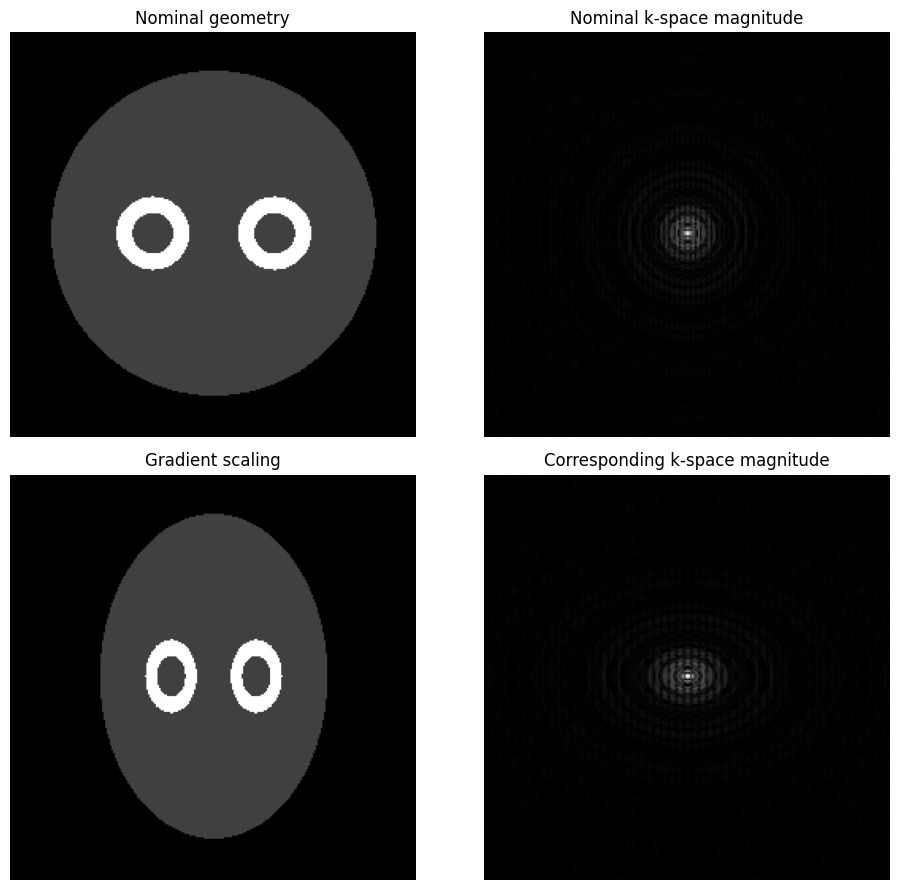

In [13]:
# Choose an example gradient error
scale_x = 0.70
scale_y = 1.00

phantom_error = generate_encoded_phantom(
    scale_x=scale_x,
    scale_y=scale_y
)

# Centered 2D Fourier transforms
kspace_nominal = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(phantom),
        norm="ortho"
    )
)

kspace_error = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(phantom_error),
        norm="ortho"
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9)
)

axes[0, 0].imshow(
    phantom,
    cmap="gray",
    origin="lower"
)

axes[0, 1].imshow(
    np.log1p(np.abs(kspace_nominal)),
    cmap="gray",
    origin="lower"
)

axes[1, 0].imshow(
    phantom_error,
    cmap="gray",
    origin="lower"
)

axes[1, 1].imshow(
    np.log1p(np.abs(kspace_error)),
    cmap="gray",
    origin="lower"
)

axes[0, 0].set_title("Nominal geometry")
axes[0, 1].set_title("Nominal k-space magnitude")

axes[1, 0].set_title("Gradient scaling")
axes[1, 1].set_title("Corresponding k-space magnitude")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 15. Your turn

Explore different combinations of gradient errors.

Try values between

$$
-30\%
\leq
\mathrm{gradient\ error}
\leq
+30\%.
$$

For example:

| $G_x$ error | $G_y$ error |
|---:|---:|
| $-30\%$ | $0\%$ |
| $+30\%$ | $0\%$ |
| $0\%$ | $-30\%$ |
| $0\%$ | $+30\%$ |
| $-20\%$ | $+20\%$ |
| $-30\%$ | $-30\%$ |
| $+30\%$ | $+30\%$ |

For each experiment:

1. Predict the geometric change.
2. Generate the reconstructed phantom.
3. Determine whether the object is compressed or expanded.
4. Identify which spatial direction is affected.
5. Consider what happened to the actual encoded FOV and spatial sampling.

Gradient scaling
----------------
Gx scale : 0.80
Gy scale : 1.20

Actual encoded FOV
------------------
FOV x : 250.00 mm
FOV y : 166.67 mm

Actual spatial sampling
-----------------------
dx : 0.9766 mm
dy : 0.6510 mm


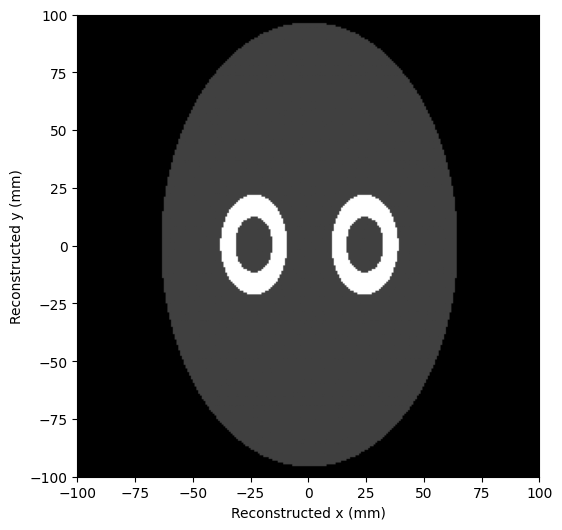

In [14]:
# --------------------------------------------------
# Change these two values
# --------------------------------------------------

Gx_error_percent = -20
Gy_error_percent = +20


# Convert percentage errors to scale factors
scale_x = 1 + Gx_error_percent / 100
scale_y = 1 + Gy_error_percent / 100


# Generate image
phantom_test = generate_encoded_phantom(
    scale_x=scale_x,
    scale_y=scale_y
)


# Actual encoded FOV
FOV_x_actual = FOV_nominal / scale_x
FOV_y_actual = FOV_nominal / scale_y


# Actual spatial sampling
dx_actual = dx_nominal / scale_x
dy_actual = dx_nominal / scale_y


# Print results
print("Gradient scaling")
print("----------------")
print(f"Gx scale : {scale_x:.2f}")
print(f"Gy scale : {scale_y:.2f}")

print("\nActual encoded FOV")
print("------------------")
print(f"FOV x : {FOV_x_actual:.2f} mm")
print(f"FOV y : {FOV_y_actual:.2f} mm")

print("\nActual spatial sampling")
print("-----------------------")
print(f"dx : {dx_actual:.4f} mm")
print(f"dy : {dy_actual:.4f} mm")


# Display result
plt.figure(figsize=(6, 6))

plt.imshow(
    phantom_test,
    cmap="gray",
    origin="lower",
    extent=[
        -FOV_nominal / 2,
         FOV_nominal / 2,
        -FOV_nominal / 2,
         FOV_nominal / 2
    ]
)

plt.xlabel("Reconstructed x (mm)")
plt.ylabel("Reconstructed y (mm)")
plt.axis("image")

plt.show()

# Questions

### 1D experiment

1. Why does changing gradient strength change the frequency-position relationship?

2. Why does changing gradient strength change the sampled k-space positions?

3. Why does a 30% reduction in gradient produce approximately a 42.9% increase in the actual encoded FOV rather than a 30% increase?

4. If the actual gradient is 30% weaker, where will a structure located at $x=50$ mm appear when reconstruction assumes the nominal gradient?

5. Is this effect a translation or a spatial scaling?

### 2D experiment

6. What happens to a circular object when only $G_x$ is reduced?

7. What happens when only $G_y$ is reduced?

8. What happens when both gradients are reduced by the same amount?

9. Why can the reconstructed geometry be incorrect even when no k-space samples are intentionally removed?

10. What information about the scanner would be required to correct a gradient-related geometric distortion?

# Take-home message

MRI gradients determine where the acquired signal is located in k-space.

For a uniform gradient amplitude error,

$$
s
=
\frac{G_{\mathrm{actual}}}
{G_{\mathrm{nominal}}}.
$$

The actual k-space coordinates scale as

$$
k_{\mathrm{actual}}
=
s\,k_{\mathrm{nominal}}.
$$

Therefore, the actual encoded FOV scales as

$$
\boxed{
\mathrm{FOV}_{\mathrm{actual}}
=
\frac{\mathrm{FOV}_{\mathrm{nominal}}}{s}
}
$$

and the actual spatial sampling interval scales as

$$
\boxed{
\Delta x_{\mathrm{actual}}
=
\frac{\Delta x_{\mathrm{nominal}}}{s}.
}
$$

If reconstruction still assumes the nominal gradient and nominal spatial calibration, image coordinates scale as

$$
\boxed{
x_{\mathrm{recon}}
=
s_xx_{\mathrm{true}}
}
$$

and

$$
\boxed{
y_{\mathrm{recon}}
=
s_yy_{\mathrm{true}}.
}
$$

A weaker-than-expected gradient therefore produces compression along that direction in an image displayed using the nominal spatial coordinates.

A stronger-than-expected gradient produces expansion.

Most importantly:

$$
\boxed{
\text{Correct Fourier reconstruction}
\neq
\text{correct physical geometry}
}
$$

if the spatial encoding assumed by reconstruction does not match the spatial encoding actually produced by the scanner.